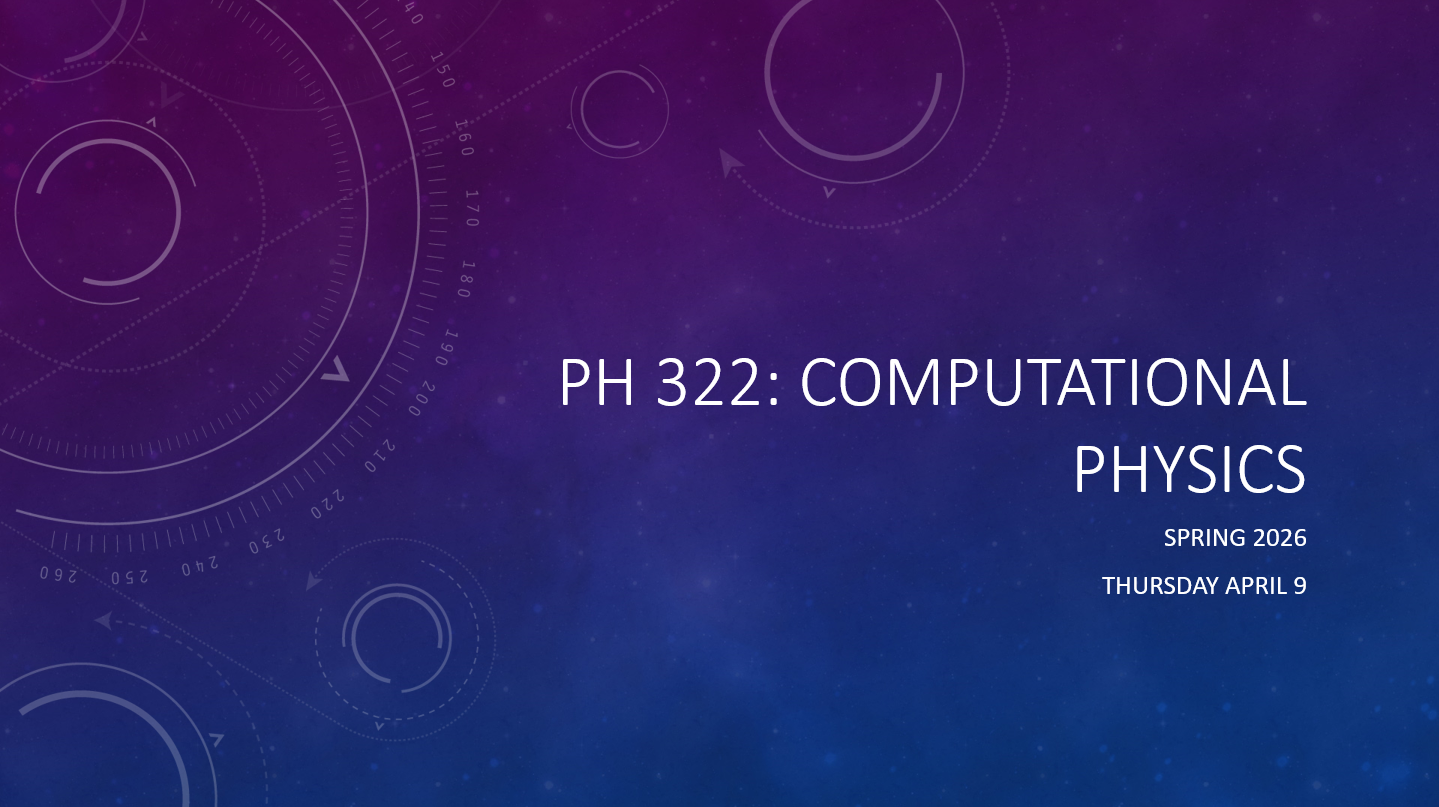

In [91]:
from IPython.display import Image, display
display(Image("G:\\My Drive\\Classes\\Ph322\\2026\\Lectures\\Figures\\header_lecture4.png"))

### Classroom survey results

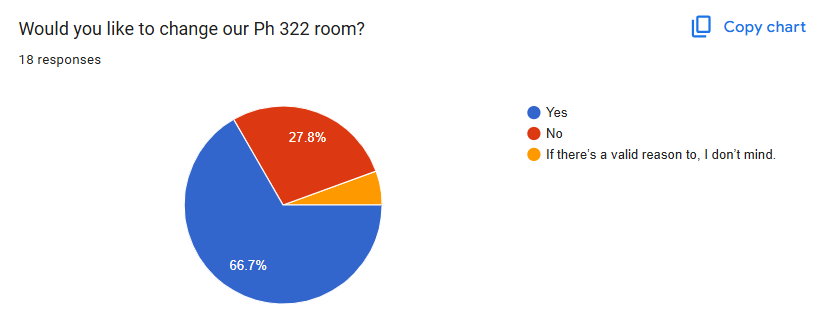

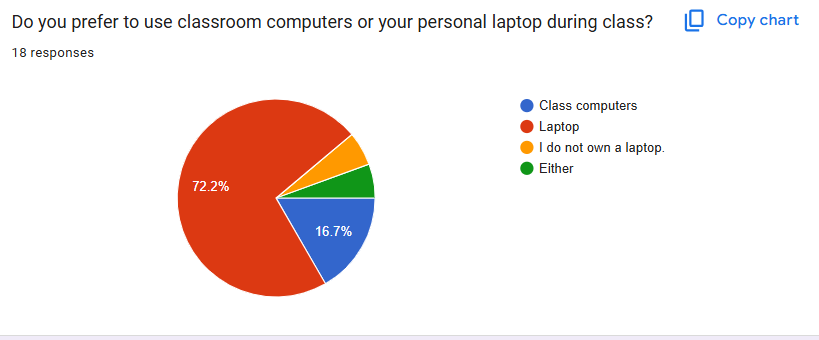


* Questions?
* HW1 48hr grace period ends tonight at 11:59pm
* HW2 posted. Due Tuesday Apr 14. 

### Last class

* NumPy package
* Creating one and multidimensional arrays
* ```np.array()```
* ```np.empty()```
* ```np.zeros()```
* ```np.arange()```
* ```np.linspace()```
* ```len()```
* ```enumerate()```
* Array slicing
* Array attributes
* Vectorization


### Today

* Creating user-defined functions
* Reading in text files
* ```np.loadtxt()```
* ```pandas```
* Making plots with ```matplotlib```

**Note:** You will need the ```numpy``` and ```matplotlib``` packages for today's class. If you don't have them already installed, you can load them "on the fly" by running this cell:

In [ ]:
%pip install numpy
%pip install matplotlib

### User-defined functions

We have already encountered a number of built-in and external Python functions, functions like ```input()```, ```print()```, ```sqrt()```, ```cos()```, etc. There will be many cases where we will need to write our own function to perform some task, e.g. calculating the value of a mathematical function for which no pre-defined function exists.  

Functions can be used for any repetitive task for which we do not want to repeat code. Using functions, we can shorten the length of our program and make our code more readable.

**Creating a function** in Python is pretty easy. The basic template looks like this:

```python
def function_name(arguments_sent_to_function):
    indented_block_of_code
    indented_block_of_code
    indented_block_of_code
    indented_block_of_code
    return <something>
```

* The keyword **def** tells Python we are defining a function.
* *function_name* is the name of the function and follows the same rules as variable names. 
* *arguments_sent_to_function* are the arguments we pass to the function. There can be one or more arguments, or no arguments at all. These can be variables like floats or integers, objects like lists or arrays, or even other functions. 
* The **def** line ends with a colon and must be followed by an indented block of code.
* The block_of_code of course is what the function does. This could be calculating a number, reading in data, making a plot, etc.
* Finally, most functions return an object, for example a float variable or a list. You can return one or more objects, or no objects at all.
* We use a function by calling it just like any other function.
* We typically define functions at the beginning of our program.
* Python ignores the function until it's called somewhere else in the program. 


### Our first function

Let's write a simple function called *m2ft()*, which converts distance in meters into feet. 

In [ ]:
# define a function to convert meters to feet

from scipy.constants import foot # "foot"is the number of meters per foot

# function to convert meters to feet
def m2ft(x):
    # x: distance in meters
    # convert x to distance in feet
    feet = x/foot # notice the calculation is done on the variable x in the function definition, not on the variable we pass to the function
    return feet # send the value of feet back to the main program

# Start of main program. Python does not execute function code until the function is called.

# prompt user for distance in meters.
distance_m = float(input("Enter distance in units of meters: "))

# This is the calling statement, where we call the function and pass the variable as an argument to the function.
distance_ft = m2ft(distance_m)

# the function m2ft returns the value of feet and we assign it to the variable distance_ft
print(f"{distance_m} meters = {distance_ft:0.2f} ft.")

This is about as simple of a function we can write. It's obvious what the function does. 

* We pass an argument *x* to the function. 
* Inside the function, x is divided by the number of meters per foot and the value of feet is returned. 
* We call the function by using the function name and including the argument we wish to pass, just like the other functions we have used.

Note: You need to define functions before you use them, so put function declarations at the beginning of your program.

### Practice Exercise

Write a function to calculate the range of a projectile launched at angle $\theta$ with initial velocity $v_o$. 

$$
x = \frac{2v_o^2}{g}\sin(\theta)\cos(\theta)
$$

Prompt the use for $v_o$ and $\theta$, then pass these to your function. Have your function return the range. 

One other note. The variables created inside functions are **local** to that function. They are not available outside the function unless we pass them with *return*. 

For example, inside my range function I convert theta to radians. If I print the value of theta outside the function, will it be the original value in degrees or the converted value in radians?

We see that if we print theta outside the function, it is still the original value. 

Also, if a function variable is not defined inside the function, the function will look for that variable outside the function. 
For example, if we define *g* inside the function above, the function will use that value. If we don't, it will use the global value of *g* we imported from scipy.

### Passing an array to a function

Typically, when you pass a variable to a function, a copy of that variable is passed, not the variable itself. 

However, if an array is passed as an argument, the memory address to the array is passed instead, meaning that changes the function makes to the array will also change the original array. 

Take this example. 

Here I create an array called A and pass it to my function. Inside the function I change the value of one of the array elements. What happens to the original array A?

In [ ]:
import numpy as np

def change(x):
    x[0]=5


# define my array
A = np.array([10, 2, 5, 4])

# print the value of A before I pass it to my function
print (f"A before function call = {A}")

# call my function and pass the array A
change(A)

# now print the array again after the function call. 
print (f"A after function call = {A}")

    

We see that the original array was changed.

If you don't want the contents of your array to change inside the function, pass a copy of the array to the function instead using the numpy function *np.copy()*:

In [ ]:
import numpy as np

def change(x):
    x[0]=5
     

# define array
A = np.array([10, 2, 5, 4])

# print A before passing it to the function
print (f"A before function call = {A}")

# now pass a copy of A to the function, not A itself
change(np.copy(A))

# print A after the function call.
print (f"A after function call = {A}")


### Returning more than one object

A function can return more than one object. It will return the objects using a tuple. 

Let's try:

In [ ]:
# define a function that returns two objects
def f(x):
    a = 2*x
    b = 3*x
    return a, b

r = 1
x = f(r)
print(x, type(x) )

The function returns both values a and b in a **tuple**. 

If we want to assign each result that is returned by the function,  we could do something like:

In [ ]:
m = f(r)[0]
n = f(r)[1]
print (m, n)

Since the function returns a tuple of size 2, index 0 references the first integer, and index 1 references the second integer.  
We could also use a single assignment statement like this:

In [ ]:
m, n = f(r)
print(m, n)

## Reading data in from a text file

It is often the case we will want to read data in from a file.

Let's say we have data stored in a text file organized into columns. For example, here is a sample of monthly sunspot data. The first column is the number of the month since January 1749, and the second column is the average daily number of sunspots. 

1	62.6  
2	70.0  
3	55.7  
4	85.0  
5	83.5  
6	94.8  
7	66.3  
8	75.9  
9	75.5  
10	158.6  
11	85.2  
12	73.3  
13	75.9  
14	89.2  
15	88.3   

There are a number of ways we can read the file. Perhaps the easiest method to read in simply formatted data such as this, is to use the ```numpy``` function ```loadtxt()```. Its syntax is 

```python
numpy.loadtxt(fname, dtype=<class 'float'>, comments='#', delimiter=None, converters=None, skiprows=0, usecols=None, unpack=False, ndmin=0, encoding='bytes', max_rows=None, *, quotechar=None, like=None)
```

The output of ```loadtext()``` is a ```numpy``` array. 

There are a number parameters we can specify that determines how the data are read in and stored in the array. The most important parameters are:

**fname: file, str**
File, filename, to read. 

**dtype: data-type, optional**
Data-type of the resulting array; default: float. 

**delimiter: str, optional**
The character used to separate the values. The default is whitespace.

**skiprows: int, optional**
Skip the first skiprows lines, including comments; default: 0.

**usecols: int or sequence, optional**
Which columns to read, with 0 being the first. For example, usecols = (1,4,5) will extract the 2nd, 5th and 6th columns. The default, None, results in all columns being read.

[More information about loadtxt()](https://numpy.org/doc/stable/reference/generated/numpy.loadtxt.html)

The output of ```loadtxt``` is a ```numpy``` array with a shape that corresponds to the data structure in the file (assuming the formatting is maintained throughout the file).

Let's try it:

In [ ]:
# demonstrate the use of np.loadtxt()

# loadtxt() is found in numpy
import numpy as np

# either one of these will work to specify the path
#file = "C:\\Users\\cbuten\\Downloads\\sunspots.txt"
#file = "C:/Users/cbuten/Downloads/sunspots.txt"
file = "G:\\My Drive\\Classes\\Ph322\\Textbooks\\Newman\\Programs and Data\\Chapter3\\sunspots.txt"

# read the data into an array 
data_array = np.loadtxt(file)
print(data_array)
print(type(data_array))

A cpl things to note. Python will look in your current working directory for your file. So you need to either put the file in your current working directory or include the full path to the file, which I do here. 

You can determine the current working directory by using the IPython/Jupyter magic character **%** followed by *pwd*.

In [ ]:
%pwd

Windows uses backslashes to format path names. However in Python strings, the backslash is an escape character that has special meaning. In order to tell Python not to treat the backslash as an escape character I use a double backslash in the path name. 

```python
path = "G:\\My Drive\\Classes\\Ph322\\Textbooks\\Newman\\Programs and Data\\Chapter3\\"
```

Alternatively, you can use forward slashes in the path string:
```python
path = "G:/My Drive/Classes/Ph322/Textbooks/Newman/Programs and Data/Chapter3/"
```


We can now examine the contents of *data_array*.  First let's examine its shape using the *shape* attribute of an *ndarray* object:

In [ ]:
# Check out the shape of data_array
data_array.shape

We see it is a 3143x2 array, meaning it has 3143 rows and 2 columns.

In [ ]:
data_array.dtype

All the elements, even the months which were integers, are floats. The default array type is float, but you can change this in *loadtxt()*.

Let's look at some of the data in the array using an array slice. What will this output? 

In [ ]:
print(data_array[:12,:])

:12 means to extract all the rows starting at 0 up to but not including index 12. And the single colon that follows, means to include all columns of data. 

We can extract the months and sunspot data and stored in 1D arrays with more meaningful names:

In [ ]:
months = data_array[:,0]
sunspots = data_array[:,1]

To grab the months, I fetch all the rows (:) but just the first column (index=0). And grab the second column (index=1) to get the sunspot data. 

Double-check if the arrays contain what we think they do: 

In [ ]:
print(months)

Yes, the months (although they have been converted to floats)

In [ ]:
print(sunspots)

Once the data are in arrays, we can plot using matplotlib.

In [ ]:
import matplotlib.pyplot as plt

plt.plot(months, sunspots)
plt.show()

### Practice Exercise 3

On Canvas in the Data and Python Files module, there is a file called "monthly_in_situ_co2_mlo.txt" that contains monthly carbon dioxide concentrations at Mauna Loa. The decimal dates are stored in the 4th column, and the CO2 concentrations in units of parts per million are stored in the 5th column.

* Download the file.
* Read the file in using ```loadtxt``` and extract the decimal dates and CO2 values.
* Make a plot of CO2 vs. date.

There are many ways to read in data from many data file formats using Python, for example Excel or netcdf files. But reading data from a tab-delimited or space-delimited text file is common and a good first step in importing data. 

### Pandas

We won't use the *pandas* package that much this term, but it is very useful to read in and work with data sets. *pandas* stores data in what is called a *dataframe* object, which is very much like a spreadsheet. 

It organizes data into rows and columns. Columns have header names that you can use to access your data. Rows can also have names or rows can be access using the index of the row. You can add additional columns to your dataframe just like a spreadsheet. 

There are entire books written on pandas, so I am only touching on its use here.

We typically import pandas as pd.

```
import pandas as pd
```

We can then use the ```pd.read_csv()``` function with the parameter ```delim_whitespace``` set to ```True```, to read our sunspot file.
I also set the parameter ```header``` to ```None``` to indicate my data file has no header line. 

The output of this function is a pandas dataframe object.

In [ ]:
import pandas as pd

#file = "C:\\Users\\cbuten\\Downloads\\sunspots.txt"
file = "G:\\My Drive\\Classes\\Ph322\\Textbooks\\Newman\\Programs and Data\\Chapter3\\sunspots.txt"

# For comma-separated values
sunspot_df = pd.read_csv(file, delim_whitespace=True, header=None)

print(type (sunspot_df))
print(sunspot_df)

We can look at the data types of each column of data using the ```dtypes``` attribute of the dataframe.



In [ ]:
sunspot_df.dtypes

Unlike ```np.loadtxt()```, pandas automatically determines the variable type of the data.

Our file did not include column headers, but we can add column headers like this:

In [ ]:
# add the column headers
sunspot_df.columns = ['months', 'sunspots']

# print first 10 rows with df.head()
print(f"\nColumn headers: \n {sunspot_df.head(10)}")


By default each row has a sequential index for a label. But we can change the labels of row using a dictionary inside the ```rename`` method:

We can grab entire columns by using the column header name:

In [ ]:
sunspot_df = sunspot_df.rename({0:'A', 1:'B', 2:'C'})
print(sunspot_df)

One of the convenient features of ```pandas``` is that we can access data values by specifying row and column names, instead of using indexing as we do with arrays.

For example, let's say I want to fetch the sunspot number from the 'C' row. I can do by specifying the row and column names inside  ```.loc```:

In [ ]:
sp = sunspot_df.loc['C', 'sunspots']   
print(sp)


We could also access this value by using NumPy-like array indexing using ```.iloc```.

Here row C is row index 2, and 'sunspots' is column index 1:

In [ ]:
sp = sunspot_df.iloc[2, 1]   
print(sp)

We can convert column data into *numpy* arrays using the *to_numpy()* method on the dataframe object. 

For example, if we want to store the sunspot data in a numpy array:

In [ ]:
# store a dataframe column as a numpy array
sunspots=sunspot_df['sunspots'].to_numpy()

print(type(sunspots))
print(sunspots)

As a final note, Pandas is good to use to read in Excel file using ```pd.read_excel()``` function:

In [ ]:
# Read the first sheet by default

excel_file = "C:\\Users\\cbuten\\Downloads\\example_file.xlsx"
df = pd.read_excel(excel_file)

print(df)

There are entire books written on Pandas. For more information about pandas, go to https://pandas.pydata.org/.

## Plotting with matplotlib  

We have already used the package ```matplotlib.pyplot``` to plot the sunspot data. Let's learn a bit more about the package.  

Let's first read the data from the *sunspots.txt* file into separate arrays like we did before:

In [ ]:
# loadtxt() is found in numpy
import numpy as np

# specify directory path and file name
file = "C:\\Users\\cbuten\\Downloads\\sunspots.txt"

# read the file data into an array 
data = np.loadtxt(file)

months = data[:,0]
sunspots = data[:,1]

Now let's make a plot of the sunspot data, with months on the x-axis and sunspots on the y-axis.

Python does not have built-in plotting functions so we have to import them. Probably the most widely-used plotting library is the module **matplotlib**. We will use the **pyplot** interface to matplotlib. 

You can make a wide variety of plots with matplotlib and I will cover only the most basic plots here. I highly recommended consulting the matplotlib website for more information and examples of plots it can make.

[matplotlib website](https://matplotlib.org/stable/plot_types/index.html)

Just some examples of the plots you can make with matplotlib.

It's common to import matplotlib.pyplot as plt,


``` 
import matplotlib.pyplot as plt
```

then prepend ```plt.``` in front of all the pyplot functions.


In [ ]:
import matplotlib.pyplot as plt

If you like, look at the list of functions available through pyplot:

In [ ]:
dir(plt)

We will use only a handful of these functions, but you will no doubt want to explore some of these on your own.

As always you can get look at the documentation for any of these functions using the *help()* command on the function name (make sure to preprend the module name)

Let's look at the documentation for one of the most useful pyplot functions, the *plot()* function:


In [ ]:
help(plt.plot)

There is a ton of information there, most we don't need, some of great interest.

First the function description sounds interesting:

*Plot y versus x as lines and/or markers.*

Sounds like what we want to do.

How do we use it?

```
plot(*args, scalex=True, scaley=True, data=None, **kwargs)
```

We need to pass it some arguments *args*, and the function also accepts some keywords, some whose values are set by default.

Let's look at some of their examples
```python
>>> plot(x, y)        # plot x and y using default line style and color
>>> plot(x, y, 'bo')  # plot x and y using blue circle markers
>>> plot(y)           # plot y using x as index array 0..N-1
>>> plot(y, 'r+')     # ditto, but with red plusses
```

So it appears the arguments we pass are the objects that contain the *x* and *y* values of our data. There is an optional argument we can pass to change the color, shape, and linestyle. 

Finally, we don't even have to pass the values for *x*. By default, *plot()** will plot the y-values against the index of each y element. 

What kinds of objects can *x* and *y* be?

The doc says they can be "array-like" or scalar. Later in the doc it says that any indexable object will work. This means we could pass our data in lists, tuples or arrays since all are indexable.

Let's give it a go:


In [ ]:
plt.plot(months, sunspots)
plt.show()

By default pyplot uses a line and the color blue.

Let's instead use red circles:

In [ ]:
plt.plot(months, sunspots, color="red", marker='o')
plt.show()

To get rid of the line use the keyword *linestyle* and set to an empty string:

In [ ]:
plt.plot(months, sunspots, color="red", marker='o', linestyle="")
plt.show()

Maybe the marker size is too big for these number of points? You can change that with another keyword "markersize":

In [ ]:
plt.plot(months, sunspots, color="red", marker='o', linestyle="", markersize=2)
plt.show()

We can change the marker edge color with the keyword *markeredgecolor*:

In [ ]:
plt.plot(months, sunspots, color="red", marker='o', linestyle="", markersize=2, markeredgecolor='b')
plt.show()

Marker edge line too thick? We can change that too with keyword *markeredgewidth*

In [ ]:
plt.plot(months, sunspots, color="red", marker='o', linestyle="", markersize=2, markeredgecolor='b', markeredgewidth=0.4)
plt.show()

I am not going to review every keyword available, but just point out you have a lot a control over how your plot looks. 

Students who have made graphs only in spreadsheet programs like Excel may find this to be a new experience of setting every graph option with a keyword, rather than with an interactive GUI. But what you give up with convenience, you get back by being able to customize nearly every aspect of your graph. 


You can also use the function *scatterplot* as a quick method of creating a scatterplot:

In [ ]:
# make a scatter plot of the sunspot data
plt.scatter(months,sunspots)
plt.show()

### Setting x and y-axis limits

To customize the range of the x-and-y axes, use the functions *xlim* and *ylim*:

In [ ]:
plt.plot(months, sunspots, "r-", ms=2)
plt.xlim(0, 100)
plt.ylim(0, 200)
plt.show()

### Setting x and y-axis labels

And to add titles to the x and y-axes, using the pyplot functions *xlabel()*, *ylabel()*, where each take the title as an argument.

In [ ]:
plt.plot(months, sunspots, "r-", ms=2)
plt.xlim(0, 100)
plt.ylim(0, 200)
plt.xlabel("Months since 1749")
plt.ylabel("Number of sunspots")
plt.show()


Often we want to plot a function to see what it looks like. 

Let's plot the $sin(\theta)$ function:

In [ ]:
from numpy import sin,linspace, pi

# use linspace to create a 1D array with 1000 values from 0 to 10 pi
x = linspace(0,10*pi,1000)

# calculate the function for every value of x and store in y
y = sin(x)

# plot y vs x. and provide a title for the x-axis
plt.plot(x,y)

# use LaTex to format theta using an r-string
plt.xlabel(r"$\theta$ (radians)")
plt.ylabel(r"$\sin\theta$")
plt.show()

Here I use "raw" strings in the plot labels by preceding each string with ```r```. Doing so, I can format text using LaTeX by enclosing the markup in dollar signs.

We can add more than one dataset to the plot. Let's overplot the sine and cosine functions.

In [ ]:
from numpy import sin, cos, linspace, pi

#def f(theta):
#    return 

# use linspace to create a 1D array with values from 0 to 10 pi
x = linspace(0,10*pi,1000)

# let's overlay sin(theta) and cos(theta)
y = sin(x)
plt.plot(x,y)

y=cos(x)
plt.plot(x,y)

plt.xlabel(r"$\theta$ (radians)")
plt.show()

And add a main title with *plt.title()*:

In [ ]:
from numpy import sin, cos, linspace, pi

#def f(theta):
#    return 

# use linspace to create a 1D array with values from 0 to 10 pi
x = linspace(0,10*pi,1000)

# let's overlay sin(theta) and cos(theta)
y = sin(x)
plt.plot(x,y)

y=cos(x)
plt.plot(x,y)

plt.xlabel(r"$\theta$ (radians)")

plt.title("Trig functions")
plt.show()

You can also add a legend to your plot by adding the keyword *label* in the *plot()* function, and using pyplot function *legend()*:

In [ ]:
from numpy import sin, cos, linspace, pi

#def f(theta):
#    return 

# use linspace to create a 1D array with values from 0 to 10 pi
x = linspace(0,10*pi,1000)

# let's overlay sin(theta) and cos(theta)
y = sin(x)
plt.plot(x,y, label=r"$\sin(\theta)$")

y=cos(x)
plt.plot(x,y, label=r"$\cos(\theta)$")

plt.xlabel(r"$\theta$ (radians)")

plt.title("Trig functions")
plt.legend()
plt.show()


If you wanted each curve to be in its own plot, you can use the function *show()* after each *plot()* call. 


In [ ]:
y = sin(x)
plt.plot(x,y, label=r"$\sin(\theta)$")
plt.show()

y=cos(x)
plt.plot(x,y, label=r"$\cos(\theta)$")


plt.xlabel(r"$\theta$ (radians)")

plt.title("Trig functions")
plt.legend()
plt.show()

But now we need to add legends individually to each plot:

In [ ]:
y = sin(x)
plt.plot(x,y, label=r"$\sin(\theta)$")
plt.xlabel(r"$\theta$ (radians)")
plt.title("Trig functions")
plt.legend()
plt.show()

y=cos(x)
plt.plot(x,y, label=r"$\cos(\theta)$")
plt.xlabel(r"$\theta$ (radians)")
plt.title("Trig functions")
plt.legend()
plt.show()

You can specify the location of the legend with a tuple containing the location of the legend in axes coordinates:

In [ ]:
y = sin(x)*cos(x)
plt.plot(x,y, label=r"$\sin(\theta)cos(\theta)$")
plt.xlabel(r"$\theta$ (radians)")
plt.title("My plot")
plt.legend(loc=(0.1,0.8))
plt.show()

There are too many features of *plot()* and *matplotlib* to review. Lots of documentation and examples of the different kinds of plots you can make with *matplotlib* is at the matplotlib website

[Gallery of Matplotlib plots](https://matplotlib.org/stable/gallery/index.html)

## Density plots

Another kind of plot we often make in physics is a surface or a density plot. A density plot is similar to an image where every point in the plot has a value, e.g. if we plot an MxN array of values. 

To see how this works, let's simply create an array of random floats and plot using the ```pyplot``` function ```imshow()```.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# generate a 100x100 array of random numbers between 0 and 1
random_array = np.random.rand(100,100)

# plot using imshow
plt.imshow(random_array)

# draw a colorbar
plt.colorbar()

We can make a few tweaks to the default plot.

First, notice that y=0 is at the top of the image, not the bottom where we normally expect it. We can flip this using the keyword *origin*:

In [ ]:
plt.imshow(random_array, origin="lower")
plt.show()

Also the labels on the x and y axes are the array indices not the physical units of the map. We might instead want to label the axes using real units that correspond with the physical dimension of the map, e.g.,  meters.

To do this we can use the keyword ```extent``` in the ```imshow()``` function. The syntax for ```extent``` is:

```python
imshow(..., extent=[xstart_value, xend_value, ystart_value, yend_value])
```

where the start and end values specify the range of the physical quantity plotted in your image.

We can also use the keyword *label* inside *colorbar()* to label the color bar:

In [ ]:
plt.imshow(random_array, origin="lower", extent=[-5,5,-5,5])
plt.xlabel("Distance, m")
plt.ylabel("Distance, m")
plt.colorbar(label="Random value")
plt.show()

Note now instead of the tick labels being array indices they are the distances, which is more useful to communicate.

We can also change the colormap used to display the image using the *cmap* keyword. You can find a list of palettes here:

[Matplotlib color palettes](https://matplotlib.org/stable/tutorials/colors/colormaps.html)

Maybe we want to use a diverging color scheme that show negative and positive potentials in different colors. Here are some diverging palettes we can choose from:

![](https://matplotlib.org/stable/_images/sphx_glr_colormaps_004.png)

Let's use the seismic scheme:

In [ ]:
# use keyword 'cmap' to change color scheme
plt.imshow(random_array, origin="lower", extent=[-5,5,-5,5], cmap="seismic")
plt.xlabel("Distance, m")
plt.ylabel("Distance, m")
plt.colorbar(label="Random value")
plt.show()

I find that not all of the colormaps listed at the matplotlib site are included with *imshow()*, so you'll have to test these a bit.


### Practice Exercise - Simple Harmonic Motion

There is a text file on Canvas called *file oscillator_data.txt* that contains measurements of the displacement of a mass on a spring over time. The first column contains the times in seconds, and the second column contains the displacments in meters. The system behaves like a simple harmonic oscillator:

$$
x(t)=A\cos(\omega t+\phi)
$$


1. Write a function that computes the displacement of a simple harmonic oscillator given the time *t*, amplitude *A*, angular frequency $\omega$, and phase $\phi$. Have your function return the displacement in meters. .

2. Read the experimental data from the file.

3. Use *matplotlib* to plot the data, using a small dot for each measurement.

4. Use your function to compute a theoretical model of the motion using estimates of $A$, $\omega$, and $\phi$, based on the measurement data.

5. Overlay the theoretical model on the measurement data with a line. Label the plot axes and include a legend.

6. Iterate steps 5 and 6 until you get a good fit.

7. If you finish, explore how to use the *scipy.optimize.curve_fit()* function to estimate these parameters and compare with your estimtes.

